In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

In [ ]:
# Dataset 
df = pd.read_csv("cleaned_dataset_without_criticalcolumns.csv")

# cluster
clusters = pd.read_csv("clusters_k2.csv")

# merge op ID
df_merged = df.merge(clusters, on="ID", how="inner")

print(df_merged.head())
print(df_merged.shape)

         ID  DestAct  NbTransf  TimePT  WalkingTimePT  WaitingTimePT  CostPT  \
0  10350017      2.0         4      85             23             10    12.4   
1  10350125      4.0         1      35             15              4     4.8   
2  10350125      4.0         1      35             15              4     4.8   
3  10350125     11.0         0      11             10              0     2.2   
4  10350125     11.0         0      11             10              0     2.2   

   CostCar  TimeCar  NbHousehold  ...  Region  distance_km  Choice  \
0     3.17       32          2.0  ...       1         30.0     1.0   
1     0.69        9          1.0  ...       1          7.0     1.0   
2     0.69        9          1.0  ...       1          7.0     1.0   
3     0.13        1          1.0  ...       1          1.0     1.0   
4     0.13        1          1.0  ...       1          1.0     1.0   

   InVehicleTime  ModeToSchool  ReportedDuration  CoderegionCAR   age  \
0           52.0         

In [7]:
# Features 
features = [col for col in df_merged.columns if col not in ['ID', 'Choice']]

X = df_merged[features]
y = df_merged['Choice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_scaled_all = scaler.fit_transform(X)


model = LogisticRegression(
    multi_class='multinomial',
    max_iter=2000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

C:\Users\fleur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'multinomial'


In [9]:
# Cross validation with accuracy scores (mean and standard deviation)
cv_scores = cross_val_score(model, X_scaled_all, y, cv=5, scoring='accuracy')
print("\nCross-Validation")
print(f"five-folder Accuracy: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f} ")

# Training the model
model.fit(X_train_scaled, y_train)

# Saving the predictions based on test data
y_pred = model.predict(X_test_scaled)

# Comparing predictions with answers
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print("\n Test Set Evaluation")
print(f"Accuracy: {acc:.4f}")
print(f" Macro F1: {macro_f1:.4f}")

# Printing the classification report
print("\nClassification Report")

print(classification_report(y_test, y_pred))

# Overview in confusion matrix
cm = confusion_matrix(y_test, y_pred)

C:\Users\fleur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\fleur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\fleur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in versio


Cross-Validation
five-folder Accuracy: [0.83150183 0.64468864 0.57875458 0.6996337  0.70588235]
Mean Accuracy: 0.6921
Standard Deviation: 0.0834 

 Test Set Evaluation
Accuracy: 0.8608
 Macro F1: 0.7915

Classification Report
              precision    recall  f1-score   support

         0.0       0.85      0.62      0.72        53
         1.0       0.88      0.95      0.91       190
         2.0       0.76      0.73      0.75        30

    accuracy                           0.86       273
   macro avg       0.83      0.77      0.79       273
weighted avg       0.86      0.86      0.86       273



C:\Users\fleur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\fleur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


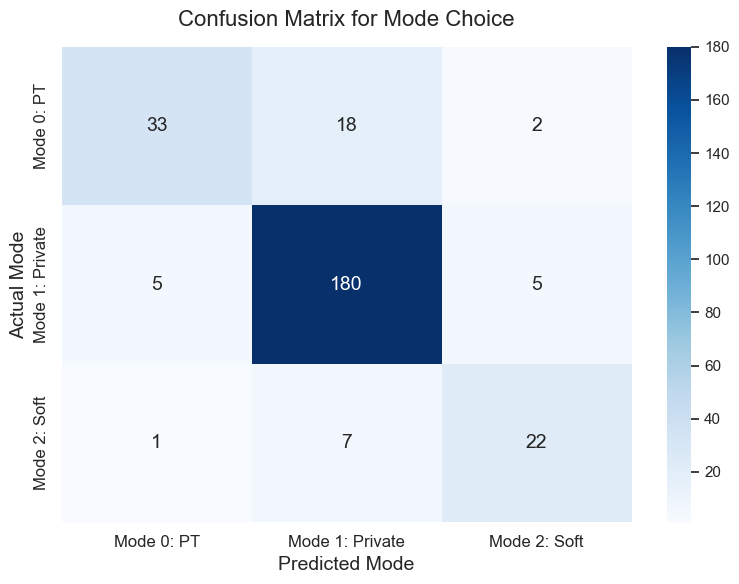

In [12]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                 xticklabels=['Mode 0: PT', 'Mode 1: Private', 'Mode 2: Soft'], 
                 yticklabels=['Mode 0: PT', 'Mode 1: Private', 'Mode 2: Soft'],
                 annot_kws={"size": 14}) 

plt.title('Confusion Matrix for Mode Choice', fontsize=16, pad=15)
plt.xlabel('Predicted Mode', fontsize=14)
plt.ylabel('Actual Mode', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# coefficients, minus value means it get worse due to clustering and positive value it gets better due to clustering
feature_names = X.columns

coef_df = pd.DataFrame(model.coef_, columns=feature_names)
coef_df['Mode'] = model.classes_
coef_df = coef_df.set_index('Mode')

print(coef_df[['Cluster_2']])

      Cluster_2
Mode           
0.0   -0.078502
1.0    0.024586
2.0    0.053917


In [14]:
groups = {
    "Socio-demographic": [
        'ID', 'age', 'Gender', 'Education', 'BirthYear', 'LangCode', 
        'Mothertongue', 'FamilSitu', 'NbHousehold', 'NbChild', 'Income', 
        'OccupStat', 'SocioProfCat', 'NbComp', 'NbTV', 'Internet', 
        'NewsPaperSubs', 'NbCellPhones', 'NbSmartPhone', 'HouseType', 
        'OwnHouse', 'NbRoomsHouse', 'YearsInHouse'
    ],
    "Vehicle": [
        'NbCar', 'NbMoto', 'NbBicy', 'NbBicyChild', 'CarAvail'
    ],
    "Subscriptions": [
        'HalfFareST', 'LineRelST', 'GenAbST', 'AreaRelST', 'OtherST'
    ],
    "Spatial": [
        'UrbRur', 'TypeCommune', 'ClassifCodeLine', 'Region', 'frequency'
    ],
    "Trip": [
        'Choice', 'TimePT', 'TimeCar', 'InVehicleTime', 'WalkingTimePT', 
        'WaitingTimePT', 'ReportedDuration', 'distance_km', 'NbTransf', 
        'CostPT', 'MarginalCostPT', 'CostCarCHF', 'CostCar'
    ],
    "History": [
        'TripPurpose', 'DestAct', 'NbTrajects', 'FreqTripHouseh', 
        'ModeToSchool', 'ResidChild', 'FreqCarPar', 'FreqTrainPar', 
        'FreqOthPar'
    ],
    "Attitudes": [
        'Envir01', 'Envir02', 'Envir03', 'Envir04', 'Envir05', 'Envir06',
        
        'Mobil01', 'Mobil02', 'Mobil03', 'Mobil04', 'Mobil05', 'Mobil06', 
        'Mobil07', 'Mobil08', 'Mobil09', 'Mobil10', 'Mobil11', 'Mobil12', 
        'Mobil13', 'Mobil14', 'Mobil15', 'Mobil16', 'Mobil17', 'Mobil18', 
        'Mobil19', 'Mobil20', 'Mobil21', 'Mobil22', 'Mobil23', 'Mobil24', 
        'Mobil25', 'Mobil26', 'Mobil27',
        
        'ResidCh01', 'ResidCh02', 'ResidCh03', 'ResidCh04', 'ResidCh05', 
        'ResidCh06', 'ResidCh07',
        
        'LifSty01', 'LifSty02', 'LifSty03', 'LifSty04', 'LifSty05', 
        'LifSty06', 'LifSty07', 'LifSty08', 'LifSty09', 'LifSty10', 
        'LifSty11', 'LifSty12', 'LifSty13', 'LifSty14'
    ]
}

In [15]:
# Zorg dat feature names bestaan
feature_names = X.columns

# Coefficients ophalen
coef = model.coef_

# Create dataframe 
coef_df = pd.DataFrame(coef, columns=feature_names)

# Add mode labels
coef_df['Mode'] = model.classes_

# Set Mode as index
coef_df = coef_df.set_index('Mode')

# Transpose 
coef_df_T = coef_df.T

# choose one for normal, two for abs value
#coef_used = coef_df_T.copy()       
coef_used = coef_df_T.abs()       

# impact average 
coef_used['mean_effect'] = coef_used.mean(axis=1)

# Sort
coef_used = coef_used.sort_values(by='mean_effect', ascending=False)

print(coef_used)

Mode                 0.0       1.0       2.0  mean_effect
InVehicleTime   1.385087  0.777459  2.162546     1.441697
TimeCar         1.795347  0.764646  1.030701     1.196898
TimePT          0.565540  0.934621  1.500162     1.000108
WaitingTimePT   1.280100  0.374647  0.905453     0.853400
NbTrajects      0.624998  0.644628  1.269626     0.846418
...                  ...       ...       ...          ...
ResidChild      0.070731  0.062670  0.008061     0.047154
Mobil09         0.013165  0.053320  0.066485     0.044324
Mobil03         0.017206  0.044802  0.062007     0.041338
LifSty02        0.034087  0.036901  0.002814     0.024601
FreqTripHouseh  0.022933  0.032716  0.009782     0.021810

[116 rows x 4 columns]


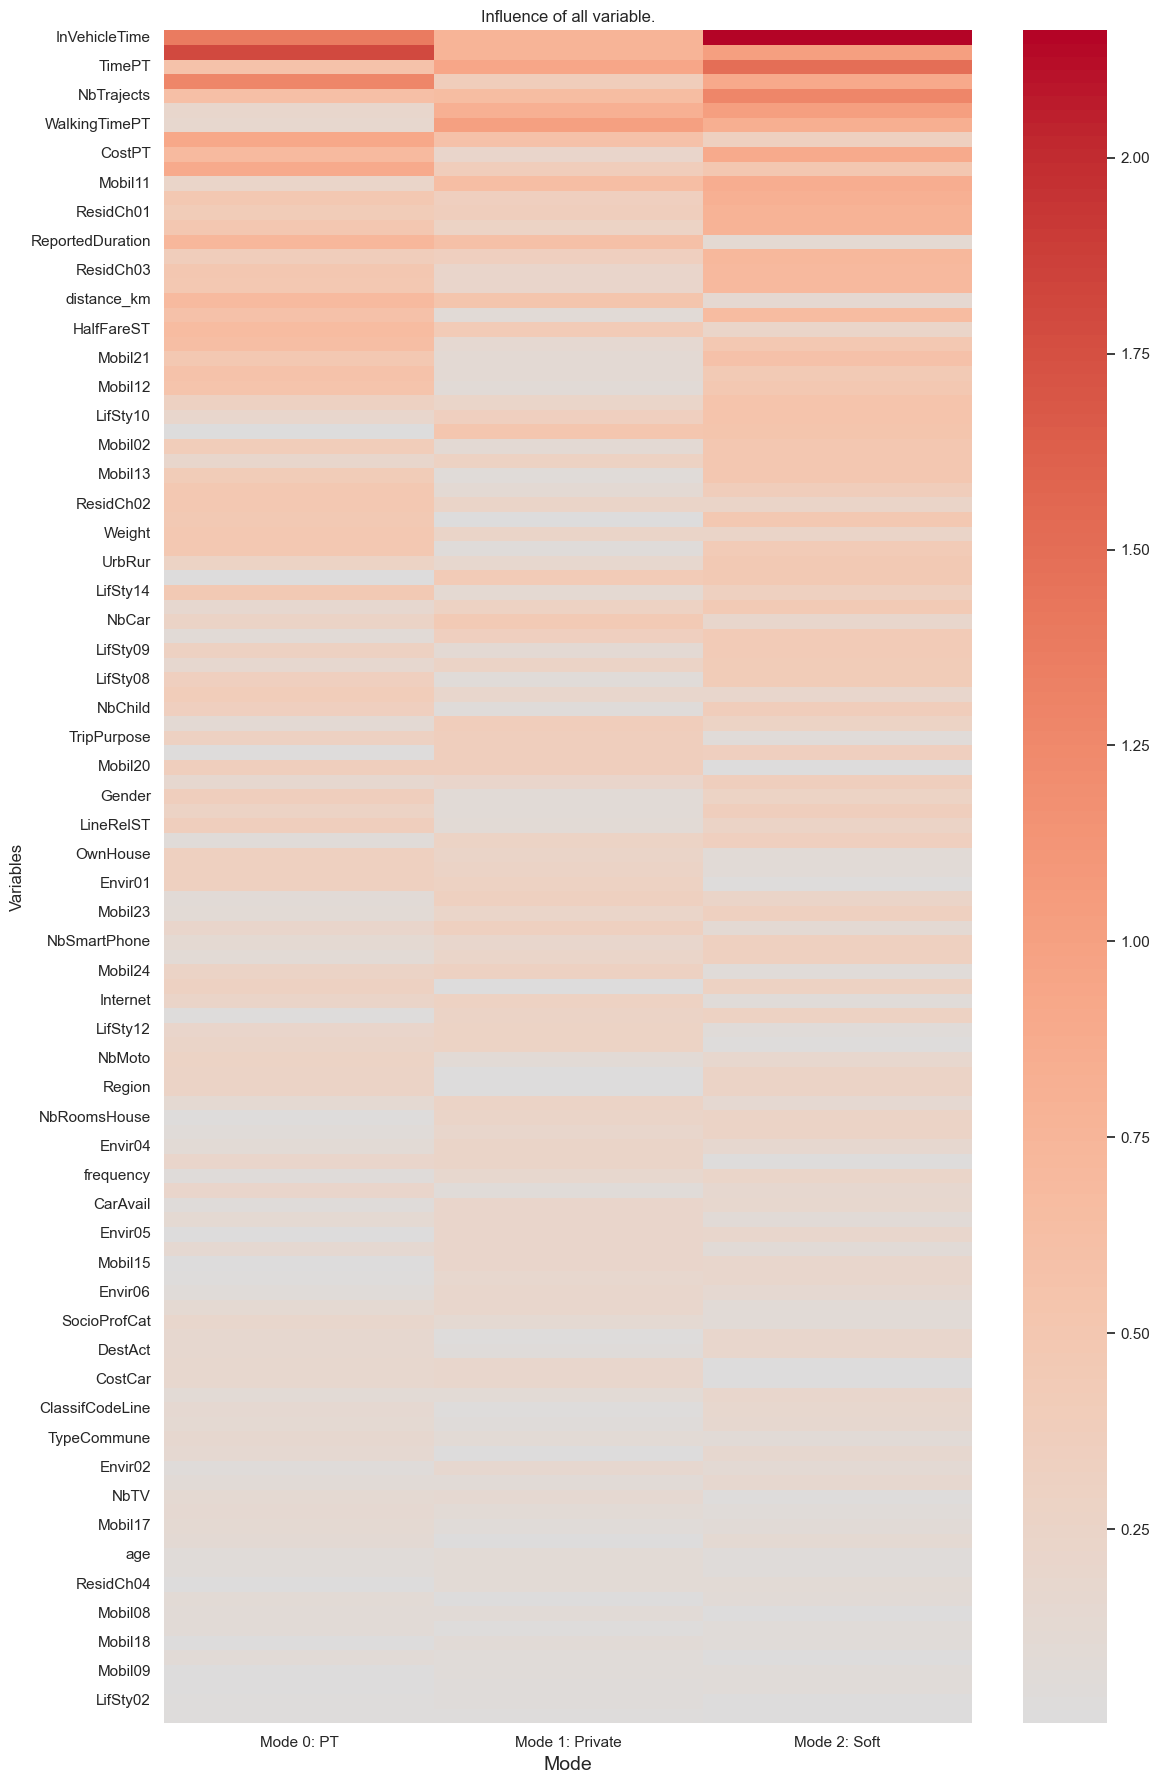

In [16]:
# Drop mean kolom
all_features = coef_used.drop(columns=['mean_effect'], errors='ignore')

plt.figure(figsize=(12, 18))

sns.heatmap(all_features, 
            cmap='coolwarm',
            center=0,
            xticklabels=['Mode 0: PT', 'Mode 1: Private', 'Mode 2: Soft'])

plt.title("Influence of all variable.")
plt.xlabel('Mode', fontsize=14)
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

In [17]:
group_mode_importance = {}

for group_name, cols in groups.items():
    existing_cols = [col for col in cols if col in coef_df_T.index]
    
    subset = coef_df_T.loc[existing_cols]

    # choose one
    #subset_used = subset.copy()        # real value
    subset_used = subset.abs()       # abs value

    group_mode_importance[group_name] = subset_used.mean(axis=0)

# Create dataframe 
group_mode_df = pd.DataFrame(group_mode_importance).T

# Sort
group_mode_df['mean_total'] = group_mode_df.mean(axis=1)
group_mode_df = group_mode_df.sort_values(by='mean_total', ascending=False)
group_mode_df = group_mode_df.drop(columns=['mean_total'])

print(group_mode_df)

Mode                    0.0       1.0       2.0
Trip               0.649068  0.526062  0.687829
Subscriptions      0.511552  0.199375  0.323769
Socio-demographic  0.291966  0.224934  0.352691
Attitudes          0.217000  0.198897  0.281801
History            0.178502  0.204016  0.275696
Vehicle            0.238844  0.215321  0.202549
Spatial            0.181511  0.098468  0.242408


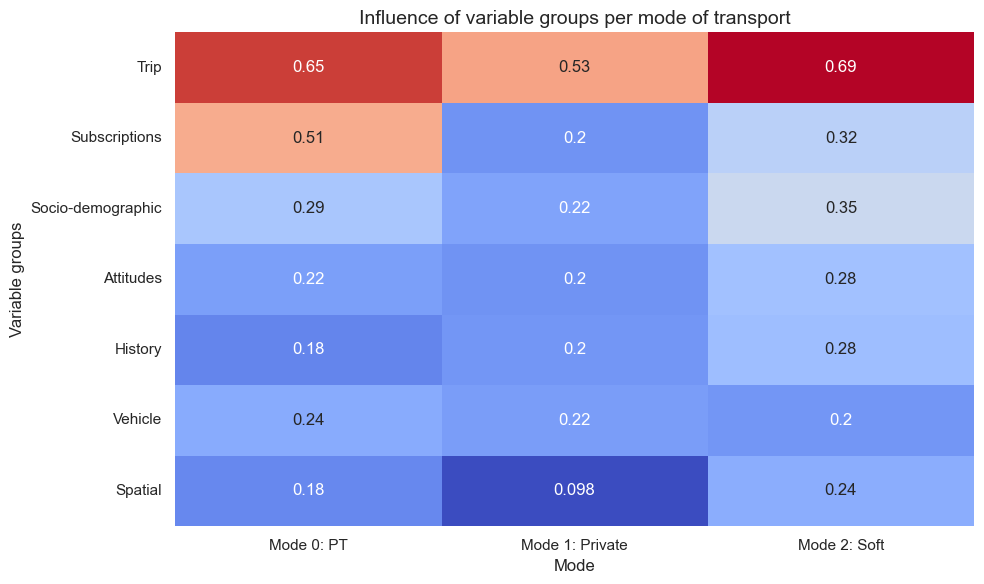

In [18]:
plt.figure(figsize=(10, 6))

sns.heatmap(group_mode_df, 
            annot=True, 
            cmap='coolwarm', 
            cbar=0,
            xticklabels=['Mode 0: PT', 'Mode 1: Private', 'Mode 2: Soft'])

plt.title("Influence of variable groups per mode of transport", fontsize=14)
plt.xlabel("Mode")
plt.ylabel("Variable groups")

plt.tight_layout()
plt.show()

In [19]:
# Bereken permutation importance op test set

result = permutation_importance(
    model, 
    X_test_scaled, 
    y_test, 
    n_repeats=10, 
    random_state=42,
    scoring='accuracy'
)

# Maak dataframe
perm_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
})

# Sorteer
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)

print(perm_importance_df)


           Feature  Importance
7          TimeCar    0.076190
3    WalkingTimePT    0.047253
2           TimePT    0.039194
109  InVehicleTime    0.038828
35         GenAbST    0.036264
..             ...         ...
51         Mobil05   -0.004762
92        LifSty12   -0.005495
88        LifSty08   -0.006227
38        CarAvail   -0.006227
13     NbBicyChild   -0.006227

[116 rows x 2 columns]


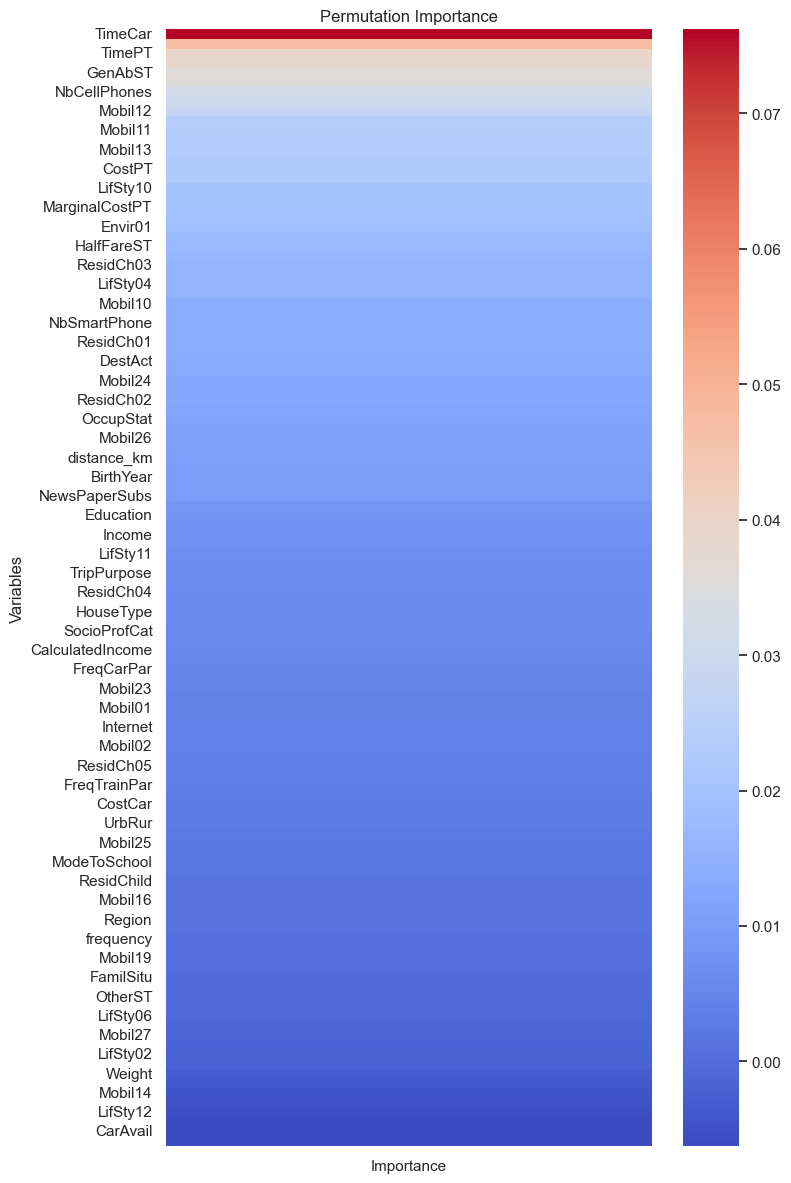

In [20]:
plt.figure(figsize=(8, 12))

sns.heatmap(
    perm_importance_df.set_index('Feature'),
    cmap='coolwarm',
    annot=False
)

plt.title("Permutation Importance")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

In [21]:
group_perm_importance = {}

for group_name, cols in groups.items():
    existing_cols = [col for col in cols if col in perm_importance_df['Feature'].values]
    
    subset = perm_importance_df[perm_importance_df['Feature'].isin(existing_cols)]
    
    group_perm_importance[group_name] = subset['Importance'].mean()

group_perm_df = pd.DataFrame.from_dict(
    group_perm_importance, 
    orient='index', 
    columns=['Importance']
)

# Sorteer
group_perm_df = group_perm_df.sort_values(by='Importance', ascending=False)

print(group_perm_df)

                   Importance
Trip                 0.025580
Subscriptions        0.014652
Socio-demographic    0.009540
History              0.008379
Attitudes            0.007733
Spatial              0.006813
Vehicle              0.005568


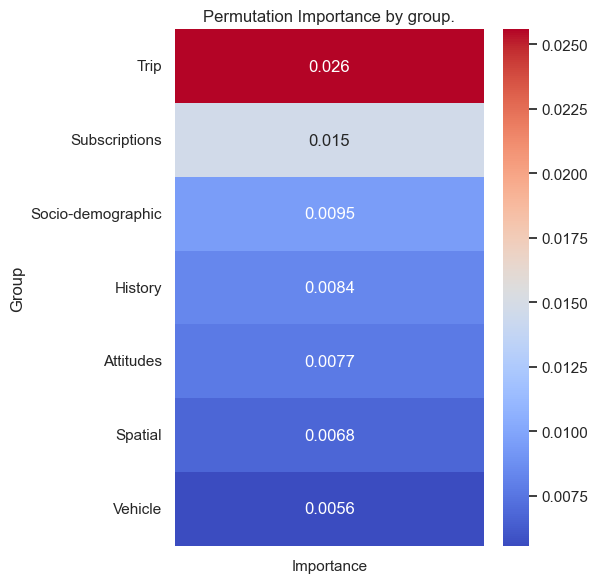

In [22]:
plt.figure(figsize=(6, 6))

sns.heatmap(
    group_perm_df,
    annot=True,
    cmap='coolwarm'
)

plt.title("Permutation Importance by group.")
plt.ylabel("Group")

plt.tight_layout()
plt.show()